# 04 — Entraînement & Évaluation
Baseline avec TF-IDF + Logistic Regression / SVM.

In [1]:
import sys
sys.path.append('..')

import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix

from embeddings import get_tfidf_vectors, load_vectorizer

In [2]:
df = pd.read_csv('../data/processed/dataset_clean.csv')
X_raw = df['clean_text'].tolist()
y     = df['class'].tolist()

# Split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)

In [3]:
# Vectorisation TF-IDF
X_train = get_tfidf_vectors(X_train_raw, fit=True)
X_test  = get_tfidf_vectors(X_test_raw,  fit=False)
print(f'Train : {X_train.shape} | Test : {X_test.shape}')

Train : (19825, 10000) | Test : (4957, 10000)


In [4]:
# --- Modèle 1 : Logistic Regression ---
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print('=== Logistic Regression ===')
print(classification_report(y_test, y_pred_lr))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.31      0.58      0.41       286
           1       0.97      0.86      0.91      3838
           2       0.79      0.94      0.86       833

    accuracy                           0.86      4957
   macro avg       0.69      0.80      0.73      4957
weighted avg       0.90      0.86      0.87      4957



In [5]:
# --- Modèle 2 : LinearSVC ---
svm = LinearSVC(class_weight='balanced', max_iter=2000)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

print('=== LinearSVC ===')
print(classification_report(y_test, y_pred_svm))

=== LinearSVC ===
              precision    recall  f1-score   support

           0       0.38      0.40      0.39       286
           1       0.94      0.93      0.93      3838
           2       0.84      0.88      0.86       833

    accuracy                           0.89      4957
   macro avg       0.72      0.74      0.73      4957
weighted avg       0.89      0.89      0.89      4957



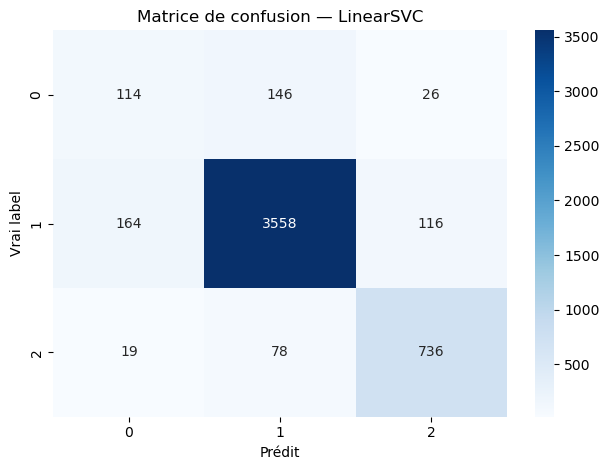

In [6]:
# Matrice de confusion — meilleur modèle
cm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matrice de confusion — LinearSVC')
plt.ylabel('Vrai label')
plt.xlabel('Prédit')
plt.tight_layout()
plt.show()

In [7]:
# Sauvegarde du meilleur modèle
with open('../models/saved/svm_model.pkl', 'wb') as f:
    pickle.dump(svm, f)
print('Modèle sauvegardé dans models/saved/svm_model.pkl')

Modèle sauvegardé dans models/saved/svm_model.pkl
